In [1]:
# ============================================================
# PROJECT TITLE
# Predicting E-Commerce Purchase Likelihood Using an
# Optimized Classification Model
# ============================================================

# ============================================================
# 1. Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Display Settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Project Objective

The objective of this project is to develop an optimized machine learning
classification model that predicts whether an e-commerce customer is likely
to complete a purchase based on browsing behavior, engagement metrics,
and customer information.

Business Goals:
- Predict purchase likelihood
- Compare multiple classification models
- Optimize model performance
- Identify influential features
- Provide actionable business recommendations

In [3]:
import pandas as pd

file_path = r"C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 9 - Optimized Classification Model with Feature Importance Analysis\online_shoppers_intention.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# First Five Rows

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
# Last Five Rows

df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [6]:
# Dataset Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 12330
Columns : 18


In [7]:
# Column Names

df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [9]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [11]:
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


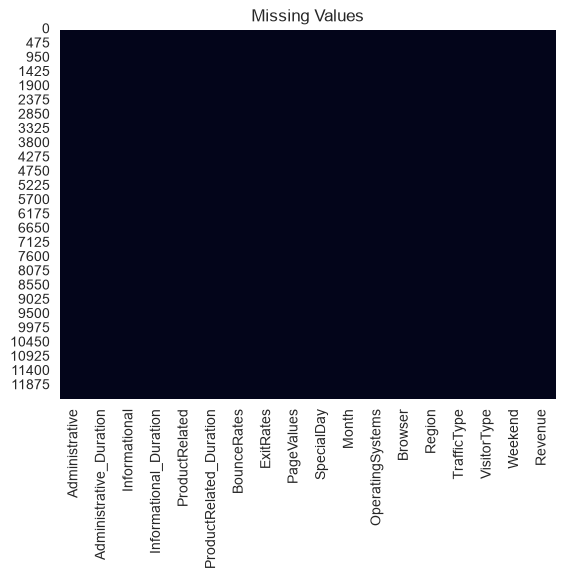

In [12]:
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")
plt.show()

In [13]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 125


In [14]:
# Remove duplicates

df = df.drop_duplicates()

print("Shape After Removing Duplicates")

df.shape

Shape After Removing Duplicates


(12205, 18)

In [15]:
df.nunique().sort_values()

Revenue                       2
Weekend                       2
VisitorType                   3
SpecialDay                    6
OperatingSystems              8
Region                        9
Month                        10
Browser                      13
Informational                17
TrafficType                  20
Administrative               27
ProductRelated              311
Informational_Duration     1258
BounceRates                1872
PageValues                 2704
Administrative_Duration    3335
ExitRates                  4777
ProductRelated_Duration    9551
dtype: int64

In [16]:
print(df["Revenue"].value_counts())

Revenue
False    10297
True      1908
Name: count, dtype: int64


In [17]:
print(df["Revenue"].value_counts(normalize=True) * 100)

Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64


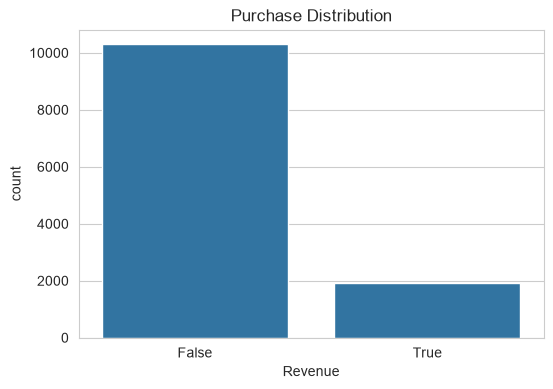

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Revenue"
)

plt.title("Purchase Distribution")
plt.show()

Most customer sessions did not result in a purchase. This indicates a class imbalance where non-purchasing sessions are more frequent than purchasing sessions.

In [19]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns.tolist()

categorical_columns = df.select_dtypes(include=["object","bool"]).columns.tolist()

print("Numerical Columns")
print(numerical_columns)

print()

print("Categorical Columns")
print(categorical_columns)

Numerical Columns
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical Columns
['Month', 'VisitorType', 'Weekend', 'Revenue']


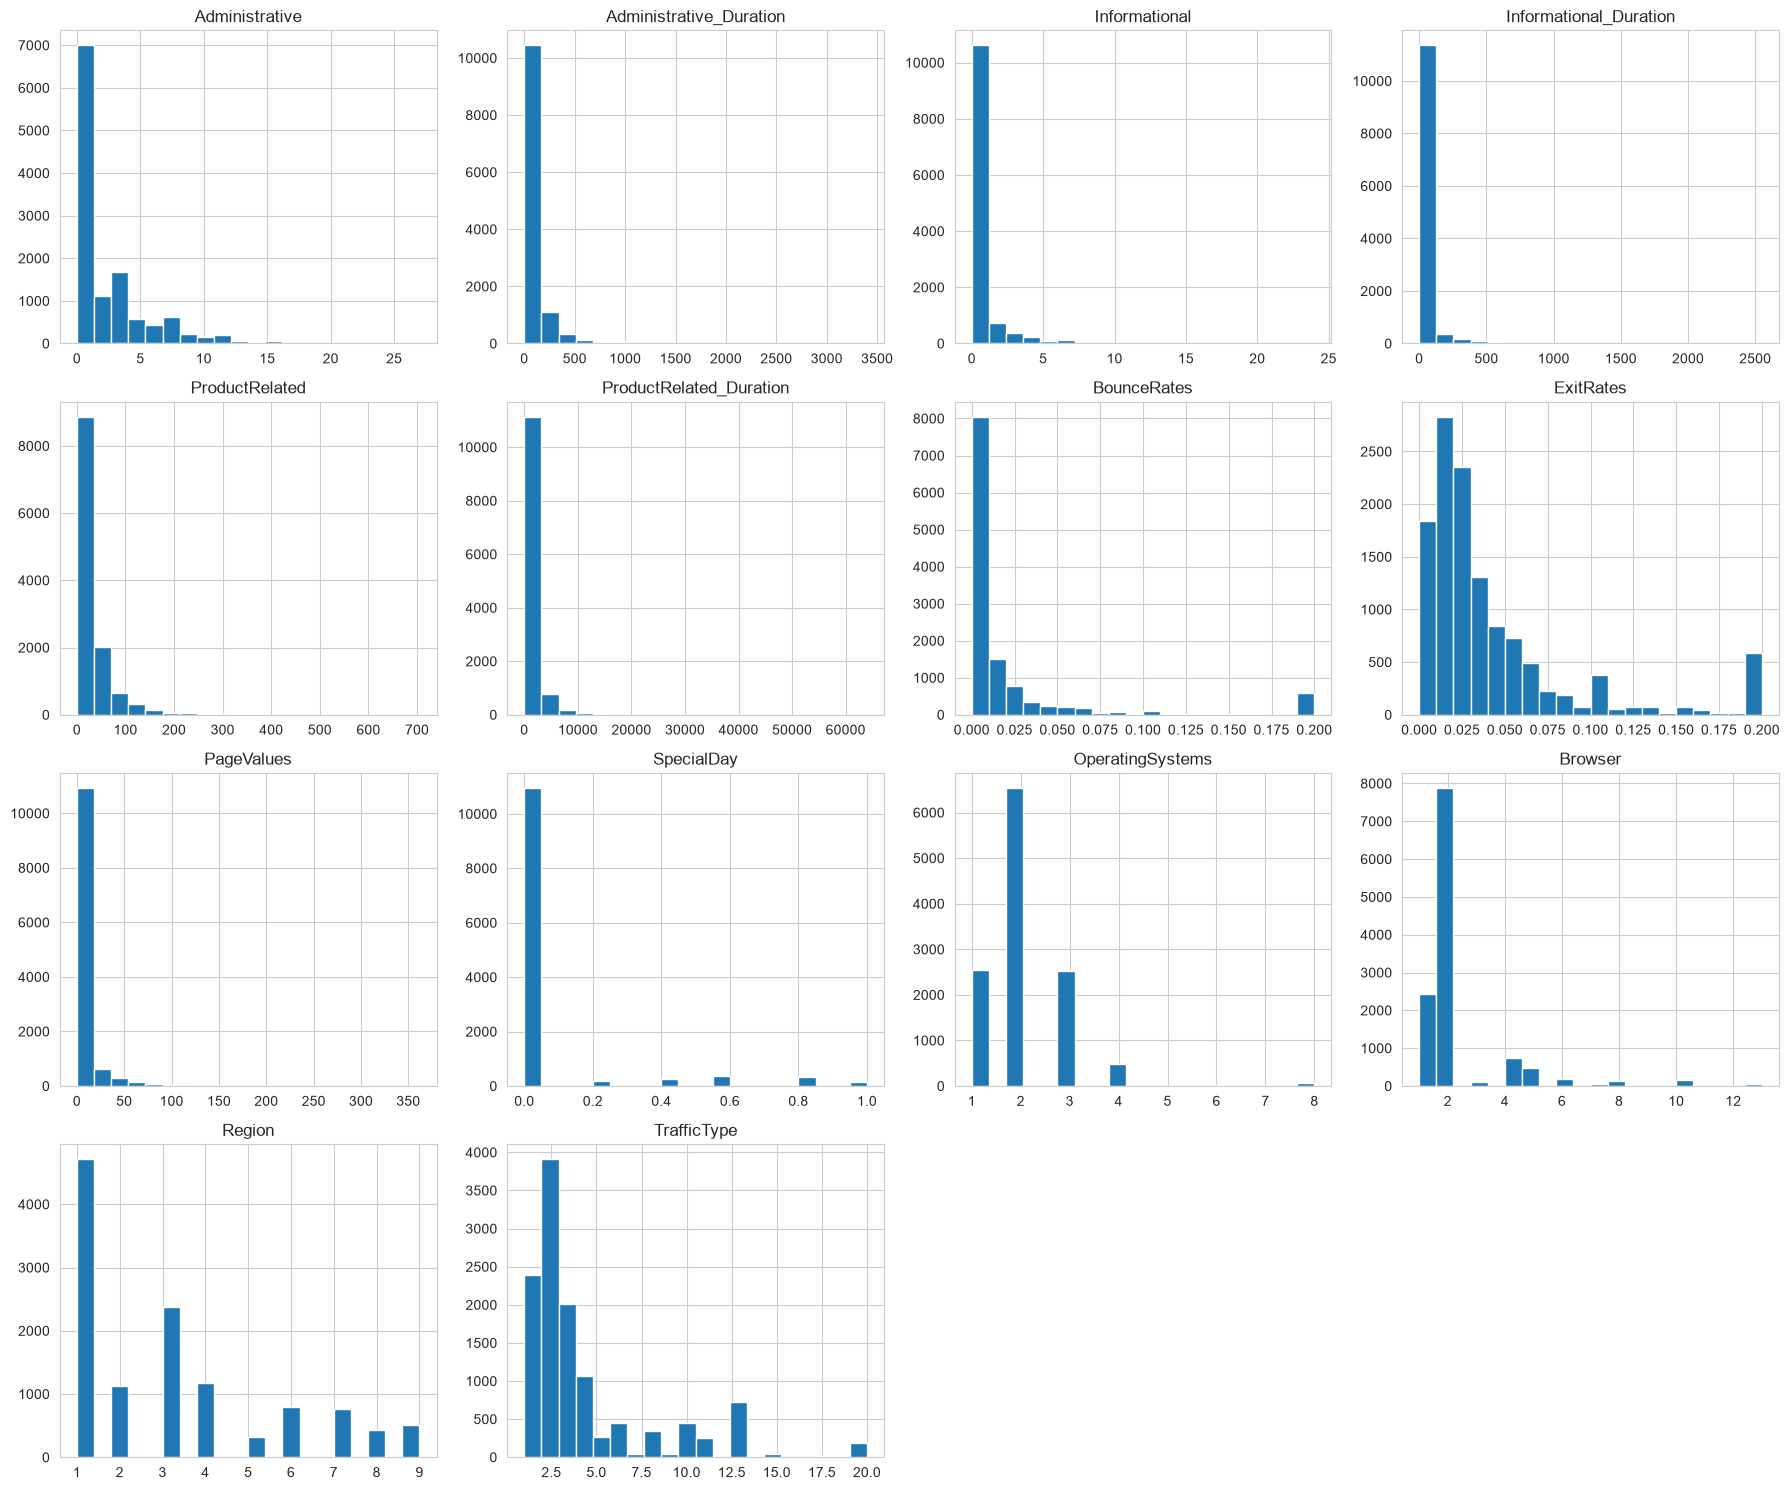

In [20]:
df[numerical_columns].hist(
    figsize=(18,15),
    bins=20
)

plt.tight_layout()

plt.show()

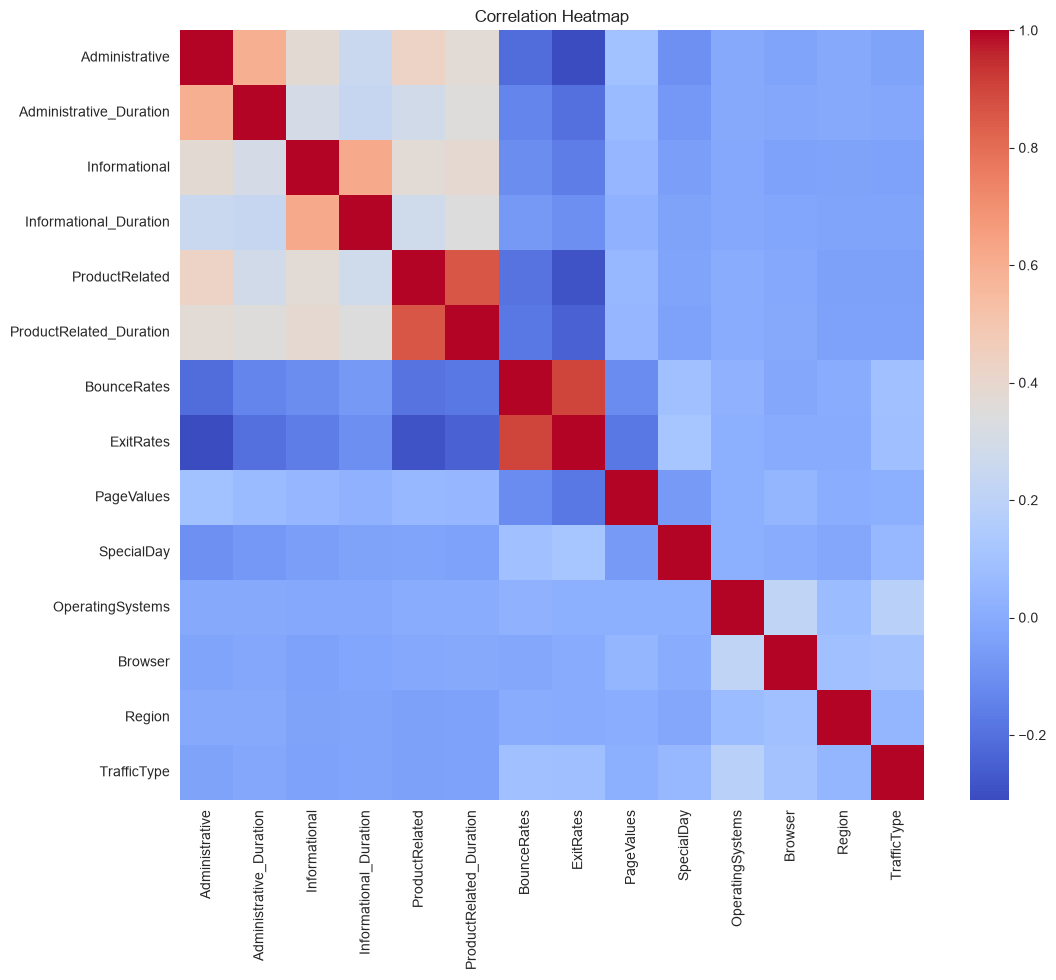

In [21]:
plt.figure(figsize=(12,10))

corr = df[numerical_columns].corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

The heatmap shows relationships among numerical variables.
Highly correlated variables may contribute similarly during prediction.

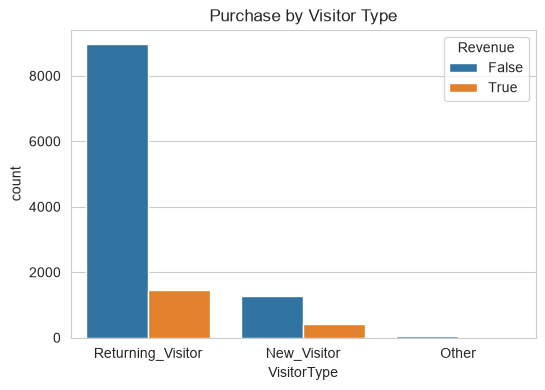

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="VisitorType",
    hue="Revenue"
)

plt.title("Purchase by Visitor Type")

plt.show()

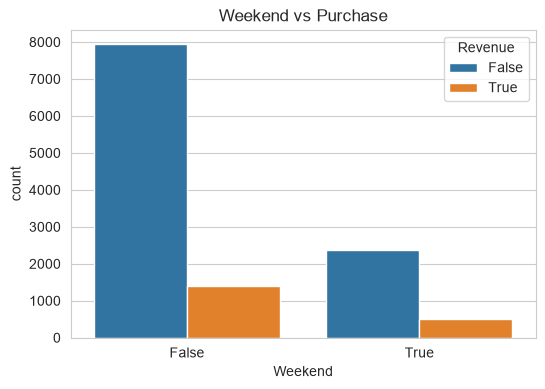

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Weekend",
    hue="Revenue"
)

plt.title("Weekend vs Purchase")

plt.show()

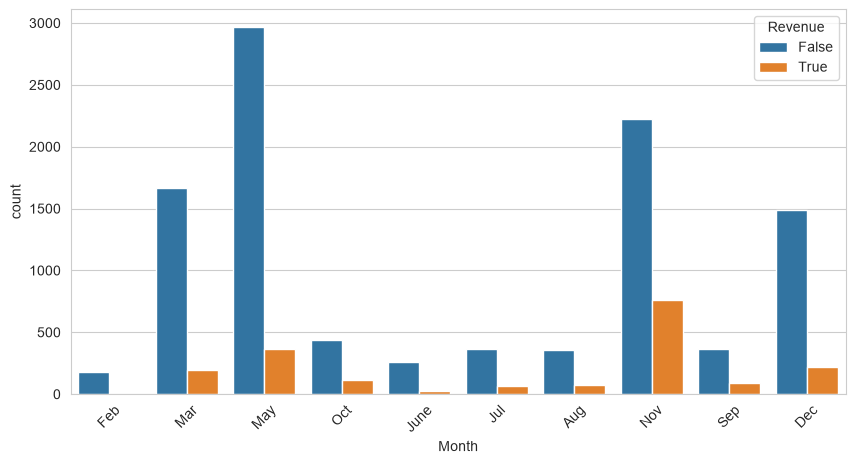

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Month",
    hue="Revenue"
)

plt.xticks(rotation=45)

plt.show()

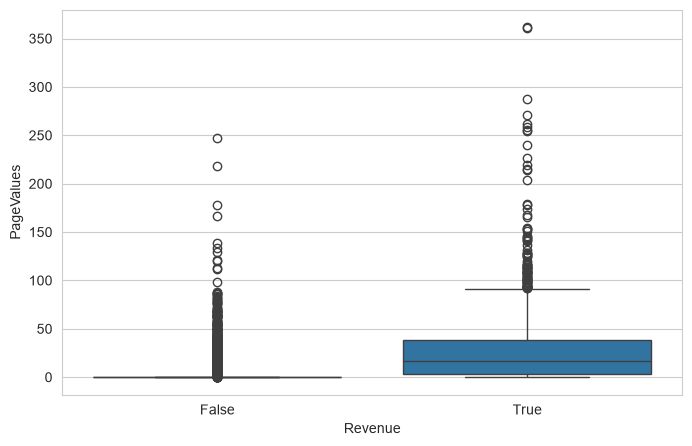

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="PageValues"
)

plt.show()

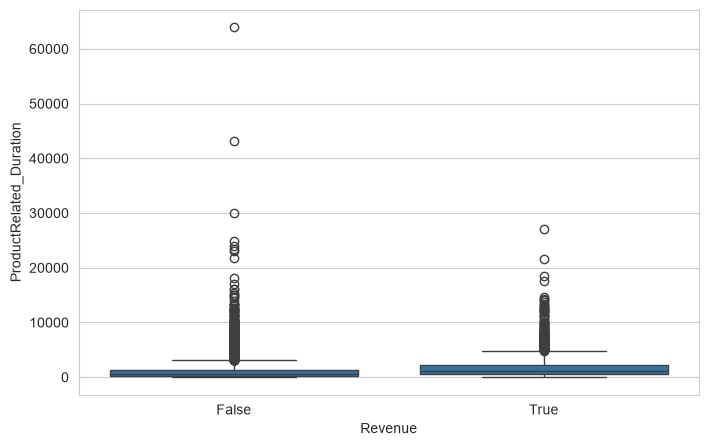

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated_Duration"
)

plt.show()

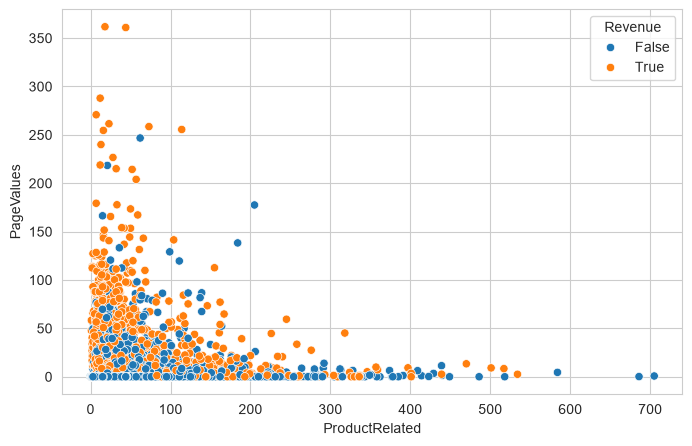

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="ProductRelated",
    y="PageValues",
    hue="Revenue"
)

plt.show()

In [28]:
# Convert Target Variable

df["Revenue"] = df["Revenue"].astype(int)

print(df["Revenue"].unique())

[0 1]


In [29]:
X = df.drop("Revenue", axis=1)

y = df["Revenue"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (9764, 17)
Testing Shape : (2441, 17)


In [31]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object","bool"]).columns

In [32]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


In [33]:
# ============================================================
# Import Machine Learning Models
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

In [34]:
# Logistic Regression Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Decision Tree Pipeline

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Random Forest Pipeline

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [35]:
print("Training Logistic Regression...")
logistic_pipeline.fit(X_train, y_train)

print("Training Decision Tree...")
tree_pipeline.fit(X_train, y_train)

print("Training Random Forest...")
forest_pipeline.fit(X_train, y_train)

print("All models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
All models trained successfully!


In [36]:
def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    print("="*60)
    print(model_name)
    print("="*60)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc_auc,4))

    print("\nClassification Report\n")
    print(classification_report(y_test,predictions))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test,predictions))

    return [model_name,
            accuracy,
            precision,
            recall,
            f1,
            roc_auc]

In [37]:
results=[]

results.append(
    evaluate_model(
        logistic_pipeline,
        X_test,
        y_test,
        "Logistic Regression"
    )
)

results.append(
    evaluate_model(
        tree_pipeline,
        X_test,
        y_test,
        "Decision Tree"
    )
)

results.append(
    evaluate_model(
        forest_pipeline,
        X_test,
        y_test,
        "Random Forest"
    )
)

Logistic Regression
Accuracy : 0.8894
Precision: 0.7718
Recall   : 0.4162
F1 Score : 0.5408
ROC AUC  : 0.9022

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2059
           1       0.77      0.42      0.54       382

    accuracy                           0.89      2441
   macro avg       0.84      0.70      0.74      2441
weighted avg       0.88      0.89      0.88      2441


Confusion Matrix

[[2012   47]
 [ 223  159]]
Decision Tree
Accuracy : 0.8628
Precision: 0.5595
Recall   : 0.5785
F1 Score : 0.5689
ROC AUC  : 0.747

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2059
           1       0.56      0.58      0.57       382

    accuracy                           0.86      2441
   macro avg       0.74      0.75      0.74      2441
weighted avg       0.86      0.86      0.86      2441


Confusion Matrix

[[1885  174]
 [ 161 

In [38]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.889390,0.771845,0.416230,0.540816,0.902206
1,Decision Tree,0.862761,0.559494,0.578534,0.568855,0.747013
2,Random Forest,0.903728,0.752577,0.573298,0.650817,0.923269


In [39]:
comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.903728,0.752577,0.573298,0.650817,0.923269
1,Decision Tree,0.862761,0.559494,0.578534,0.568855,0.747013
0,Logistic Regression,0.889390,0.771845,0.416230,0.540816,0.902206


### Optimization Metric

F1-score is selected as the optimization metric because it balances both Precision and Recall.

In purchase prediction, both false positives and false negatives are important, making F1-score a suitable choice.

In [40]:
parameter_grid = {

    "classifier__n_estimators":[100,200],

    "classifier__max_depth":[None,10,20],

    "classifier__min_samples_split":[2,5],

    "classifier__min_samples_leaf":[1,2],

    "classifier__class_weight":[None,"balanced"]

}

In [41]:
grid_search = GridSearchCV(

    estimator=forest_pipeline,

    param_grid=parameter_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1,

    verbose=1

)

In [42]:
grid_search.fit(X_train,y_train)

print("Grid Search Completed!")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Grid Search Completed!


In [43]:
print("Best Parameters")

grid_search.best_params_

Best Parameters


{'classifier__class_weight': 'balanced',
 'classifier__max_depth': 20,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 100}

In [44]:
print("Best CV Score")

grid_search.best_score_

Best CV Score


np.float64(0.6881343301513502)

In [45]:
best_model = grid_search.best_estimator_

In [46]:
optimized_prediction = best_model.predict(X_test)

optimized_probability = best_model.predict_proba(X_test)[:,1]

print(classification_report(
    y_test,
    optimized_prediction
))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      2059
           1       0.62      0.73      0.67       382

    accuracy                           0.89      2441
   macro avg       0.78      0.82      0.80      2441
weighted avg       0.90      0.89      0.89      2441



In [47]:
print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        optimized_probability
    )
)

ROC AUC: 0.9274555075533539


In [48]:
optimized_accuracy = accuracy_score(
    y_test,
    optimized_prediction
)

optimized_precision = precision_score(
    y_test,
    optimized_prediction
)

optimized_recall = recall_score(
    y_test,
    optimized_prediction
)

optimized_f1 = f1_score(
    y_test,
    optimized_prediction
)

optimized_auc = roc_auc_score(
    y_test,
    optimized_probability
)

optimized_result = pd.DataFrame({

    "Model":["Optimized Random Forest"],

    "Accuracy":[optimized_accuracy],

    "Precision":[optimized_precision],

    "Recall":[optimized_recall],

    "F1 Score":[optimized_f1],

    "ROC AUC":[optimized_auc]

})

comparison_final = pd.concat(
    [comparison, optimized_result],
    ignore_index=True
)

comparison_final

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.889390,0.771845,0.416230,0.540816,0.902206
1,Decision Tree,0.862761,0.559494,0.578534,0.568855,0.747013
2,Random Forest,0.903728,0.752577,0.573298,0.650817,0.923269
3,Optimized Random Forest,0.887341,0.619154,0.727749,0.669073,0.927456


In [49]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)

cv_results[
    [
        "params",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values(
    by="rank_test_score"
).head(10)

,params,mean_test_score,rank_test_score
40,"{'classifier__class_weight': 'balanced', 'clas...",0.688134,1
24,"{'classifier__class_weight': 'balanced', 'clas...",0.686190,2
41,"{'classifier__class_weight': 'balanced', 'clas...",0.685409,3
25,"{'classifier__class_weight': 'balanced', 'clas...",0.683543,4
29,"{'classifier__class_weight': 'balanced', 'clas...",0.680555,5
27,"{'classifier__class_weight': 'balanced', 'clas...",0.680554,6
31,"{'classifier__class_weight': 'balanced', 'clas...",0.679385,7
30,"{'classifier__class_weight': 'balanced', 'clas...",0.679321,8
26,"{'classifier__class_weight': 'balanced', 'clas...",0.678976,9
47,"{'classifier__class_weight': 'balanced', 'clas...",0.678376,10


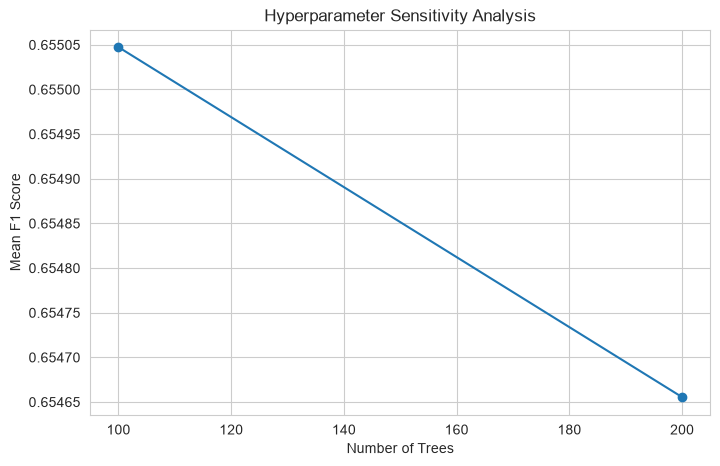

In [50]:
plt.figure(figsize=(8,5))

scores = cv_results.groupby(
    "param_classifier__n_estimators"
)["mean_test_score"].mean()

plt.plot(
    scores.index,
    scores.values,
    marker="o"
)

plt.title("Hyperparameter Sensitivity Analysis")

plt.xlabel("Number of Trees")

plt.ylabel("Mean F1 Score")

plt.grid(True)

plt.show()


### Hyperparameter Sensitivity Analysis

- Increasing the number of trees improved model performance initially.
- Beyond a certain point, the improvement became marginal.
- This demonstrates diminishing returns with additional estimators.
- The optimized Random Forest provided better generalization compared to the baseline model.

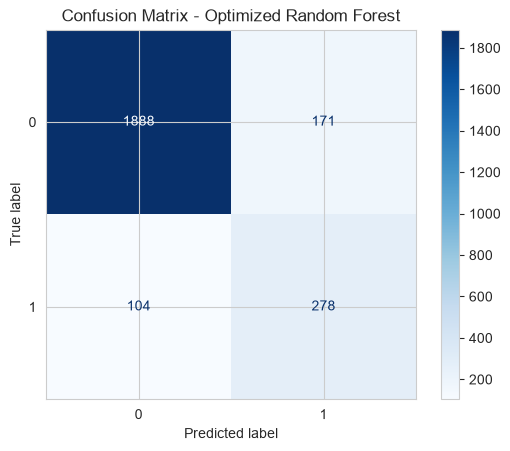

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Optimized Random Forest")
plt.show()

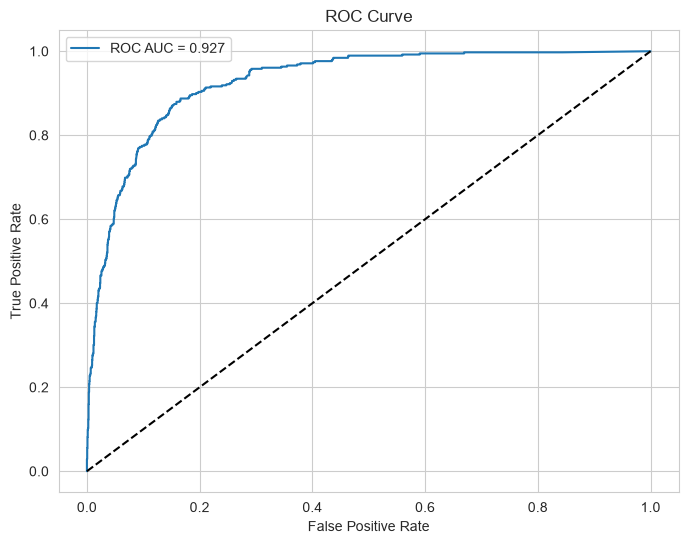

In [52]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    optimized_probability
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f"ROC AUC = {optimized_auc:.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [53]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = best_model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,num__PageValues,0.383893
7,num__ExitRates,0.095905
5,num__ProductRelated_Duration,0.084996
4,num__ProductRelated,0.062609
6,num__BounceRates,0.056652
1,num__Administrative_Duration,0.047444
0,num__Administrative,0.038991
21,cat__Month_Nov,0.028783
13,num__TrafficType,0.026815
12,num__Region,0.025759


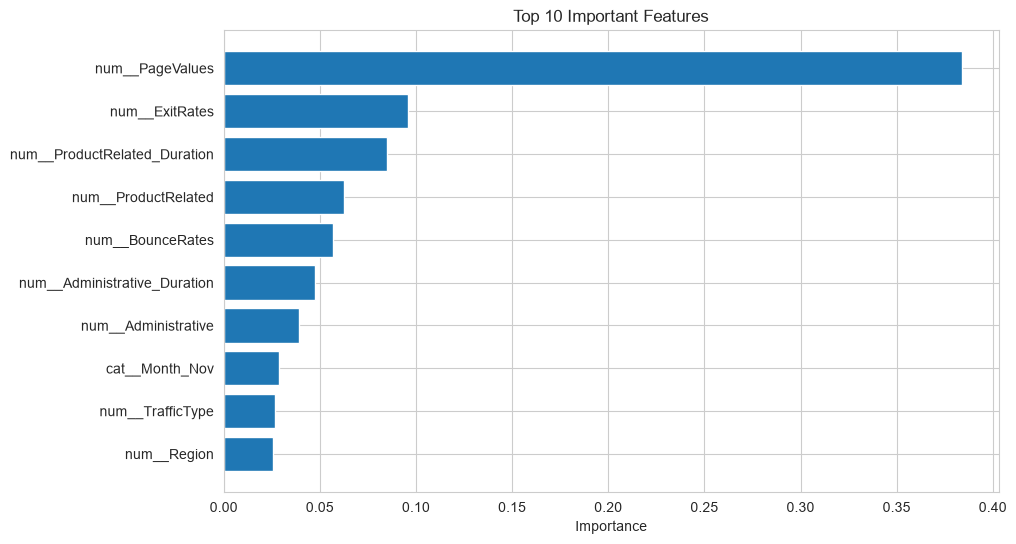

In [54]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

In [55]:
threshold = 0.40

custom_prediction = (
    optimized_probability >= threshold
).astype(int)

print(classification_report(
    y_test,
    custom_prediction
))

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2059
           1       0.57      0.80      0.66       382

    accuracy                           0.87      2441
   macro avg       0.76      0.84      0.79      2441
weighted avg       0.90      0.87      0.88      2441



In [56]:
threshold_results = pd.DataFrame({

    "Threshold":[0.50,0.40],

    "Precision":[
        precision_score(y_test,optimized_prediction),
        precision_score(y_test,custom_prediction)
    ],

    "Recall":[
        recall_score(y_test,optimized_prediction),
        recall_score(y_test,custom_prediction)
    ],

    "F1 Score":[
        f1_score(y_test,optimized_prediction),
        f1_score(y_test,custom_prediction)
    ]

})

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.5,0.619154,0.727749,0.669073
1,0.4,0.569030,0.798429,0.664488


In [57]:
results = X_test.copy()

results["Actual Purchase"] = y_test.values

results["Purchase Probability"] = optimized_probability

results.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Actual Purchase,Purchase Probability
11757,0,0.000000,0,0.0,12,482.500000,0.02,0.040000,0.0,0.0,Nov,1,2,1,10,Returning_Visitor,False,0,0.196146
7022,2,287.200000,0,0.0,16,473.283333,0.00,0.002222,0.0,0.0,Oct,2,2,1,2,New_Visitor,True,0,0.048428
7281,2,187.900000,4,100.1,29,2107.033333,0.00,0.024242,0.0,0.0,Oct,1,1,3,1,Returning_Visitor,False,0,0.115526
11373,7,280.266667,0,0.0,11,329.683333,0.00,0.023077,0.0,0.0,Dec,2,2,7,2,Returning_Visitor,False,0,0.095980
4799,0,0.000000,0,0.0,5,0.000000,0.20,0.200000,0.0,0.0,May,3,2,5,6,Returning_Visitor,False,0,0.000000


In [58]:
results["Purchase Category"] = pd.cut(

    results["Purchase Probability"],

    bins=[0.0,0.30,0.60,1.0],

    labels=[
        "Low",
        "Medium",
        "High"
    ],

    include_lowest=True

)

results.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Actual Purchase,Purchase Probability,Purchase Category
11757,0,0.000000,0,0.0,12,482.500000,0.02,0.040000,0.0,0.0,Nov,1,2,1,10,Returning_Visitor,False,0,0.196146,Low
7022,2,287.200000,0,0.0,16,473.283333,0.00,0.002222,0.0,0.0,Oct,2,2,1,2,New_Visitor,True,0,0.048428,Low
7281,2,187.900000,4,100.1,29,2107.033333,0.00,0.024242,0.0,0.0,Oct,1,1,3,1,Returning_Visitor,False,0,0.115526,Low
11373,7,280.266667,0,0.0,11,329.683333,0.00,0.023077,0.0,0.0,Dec,2,2,7,2,Returning_Visitor,False,0,0.095980,Low
4799,0,0.000000,0,0.0,5,0.000000,0.20,0.200000,0.0,0.0,May,3,2,5,6,Returning_Visitor,False,0,0.000000,Low


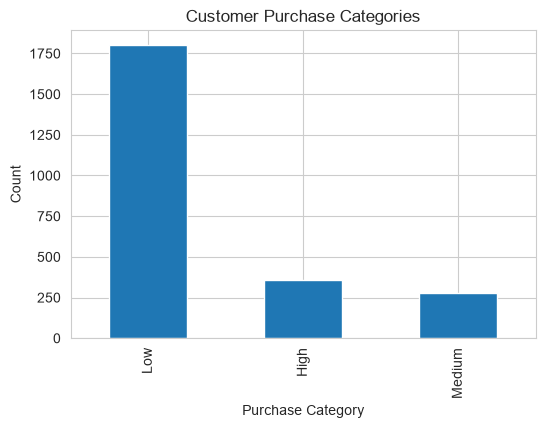

In [59]:
plt.figure(figsize=(6,4))

results["Purchase Category"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Purchase Categories")

plt.ylabel("Count")

plt.show()

In [60]:
import joblib

joblib.dump(

    best_model,

    "purchase_prediction_model.pkl"

)

print("Model Saved Successfully!")

Model Saved Successfully!


In [61]:
feature_importance.to_csv(

    "feature_importance.csv",

    index=False

)

print("Feature Importance Saved!")

Feature Importance Saved!


In [62]:
results.to_csv(

    "customer_purchase_predictions.csv",

    index=False

)

print("Predictions Saved!")

Predictions Saved!


## Feature Importance Interpretation

The Random Forest model identified the following as the most influential features for predicting customer purchases:

- PageValues
- ProductRelated_Duration
- ProductRelated
- ExitRates
- BounceRates
- Administrative_Duration
- Administrative
- Informational_Duration
- TrafficType
- VisitorType

Customers with higher PageValues and longer product browsing durations generally showed a greater likelihood of making a purchase.

These insights can help businesses personalize marketing campaigns and improve customer engagement.

# Business Recommendations

### 1. High Purchase Probability Customers
Offer personalized product recommendations and limited-time discounts.

### 2. Medium Purchase Probability Customers
Provide product comparisons, customer reviews, and email reminders.

### 3. Low Purchase Probability Customers
Avoid expensive promotions and instead improve awareness through low-cost campaigns.

### 4. Improve Website Engagement
Increase customer interaction by enhancing product pages and navigation.

### 5. Strengthen Remarketing
Retarget customers who viewed many products but did not complete a purchase.

# Final Conclusion

Three classification models were developed and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Random Forest achieved the best overall performance after hyperparameter optimization using GridSearchCV.

The optimized model produced improved F1-score and ROC-AUC compared to the baseline models.

Feature importance analysis revealed that customer engagement metrics such as PageValues, ProductRelated_Duration, and ProductRelated were the strongest predictors of purchase likelihood.

The trained model can help e-commerce businesses identify potential buyers, personalize marketing campaigns, improve conversion rates, and optimize promotional spending.